# Machine learning

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

### 1.Business understanding

#### 2.Data collection

In [18]:
insurance_data=pd.read_csv(filepath_or_buffer="insurance data.csv")
insurance_data

,CASENUM,ATTORNEY,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,5,0,0.0,1.0,0.0,50.0,34.940
1,3,1,1.0,0.0,0.0,18.0,0.891
2,66,1,0.0,1.0,0.0,5.0,0.330
3,70,0,0.0,1.0,1.0,31.0,0.037
4,96,1,0.0,1.0,0.0,30.0,0.038
...,...,...,...,...,...,...,...
1335,34100,1,0.0,1.0,0.0,NaN,0.576
1336,34110,0,1.0,1.0,0.0,46.0,3.705
1337,34113,1,1.0,1.0,0.0,39.0,0.099
1338,34145,0,1.0,0.0,0.0,8.0,3.177


#### 3.Data understanding

In [19]:
insurance_data.shape

(1340, 7)

In [20]:
insurance_data.isna().sum()

CASENUM       0
ATTORNEY      0
CLMSEX       12
CLMINSUR     41
SEATBELT     48
CLMAGE      189
LOSS          0
dtype: int64

In [21]:
insurance_data.dtypes

CASENUM       int64
ATTORNEY      int64
CLMSEX      float64
CLMINSUR    float64
SEATBELT    float64
CLMAGE      float64
LOSS        float64
dtype: object

#### 4.Data preperation

##### 4.1 Data cleaning 

In [22]:
insurance_data=insurance_data.dropna()
insurance_data

,CASENUM,ATTORNEY,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,5,0,0.0,1.0,0.0,50.0,34.940
1,3,1,1.0,0.0,0.0,18.0,0.891
2,66,1,0.0,1.0,0.0,5.0,0.330
3,70,0,0.0,1.0,1.0,31.0,0.037
4,96,1,0.0,1.0,0.0,30.0,0.038
...,...,...,...,...,...,...,...
1334,34104,1,1.0,1.0,0.0,16.0,0.060
1336,34110,0,1.0,1.0,0.0,46.0,3.705
1337,34113,1,1.0,1.0,0.0,39.0,0.099
1338,34145,0,1.0,0.0,0.0,8.0,3.177


##### 4.2 Data seperation

In [23]:
x=insurance_data.drop(labels="ATTORNEY",axis=1)
x

,CASENUM,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,5,0.0,1.0,0.0,50.0,34.940
1,3,1.0,0.0,0.0,18.0,0.891
2,66,0.0,1.0,0.0,5.0,0.330
3,70,0.0,1.0,1.0,31.0,0.037
4,96,0.0,1.0,0.0,30.0,0.038
...,...,...,...,...,...,...
1334,34104,1.0,1.0,0.0,16.0,0.060
1336,34110,1.0,1.0,0.0,46.0,3.705
1337,34113,1.0,1.0,0.0,39.0,0.099
1338,34145,1.0,0.0,0.0,8.0,3.177


In [24]:
y=insurance_data.drop(labels= ["CLMSEX","CLMINSUR","SEATBELT","CLMAGE","LOSS","CASENUM"],axis=1)
y

,ATTORNEY
0,0
1,1
2,1
3,0
4,1
...,...
1334,1
1336,0
1337,1
1338,0


#### 5.Model Building

In [25]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [39]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test =train_test_split(x,y,test_size=0.20,shuffle=True)
x_train,x_test,y_train,y_test
logistic_model=LogisticRegression()

#### 6.Model training

In [40]:
logistic_model.fit(x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


#### 7.Model testing 

##### 7.1 training data

In [41]:
y_pred_train=logistic_model.predict(x_train)
print(y_pred_train)

[1 0 1 1 1 0 1 0 0 0 1 0 1 0 1 1 0 1 1 0 1 1 1 0 1 0 1 1 1 1 1 1 0 0 0 1 0
 1 1 1 1 0 1 1 1 0 0 1 1 1 0 1 0 0 0 0 1 0 0 0 1 0 1 0 1 1 1 1 0 1 0 0 0 1
 0 1 0 0 1 1 0 1 0 0 1 0 1 1 1 0 1 0 1 0 0 1 0 1 0 0 1 0 0 0 1 1 0 1 1 0 0
 0 0 1 1 1 1 1 1 0 1 1 1 1 1 0 0 1 0 0 1 0 0 1 0 1 1 0 0 1 1 1 0 0 0 0 1 1
 0 1 1 1 0 1 1 0 0 1 1 1 0 0 1 1 0 1 0 1 0 1 0 1 1 0 1 1 1 1 1 1 1 1 0 0 1
 1 0 1 0 1 0 0 1 0 0 0 1 1 0 1 0 1 0 1 1 1 1 1 0 0 1 1 1 1 1 1 0 1 1 0 0 0
 0 0 1 1 1 1 1 0 1 0 0 1 0 0 1 1 1 1 0 1 1 1 1 1 0 1 0 1 1 1 0 1 1 0 1 1 1
 1 0 0 0 1 1 1 0 1 1 1 1 0 1 0 0 0 0 0 0 1 1 1 0 1 1 1 0 1 0 0 0 0 0 1 1 1
 0 0 0 1 1 0 0 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 0 0 1 0 0 0 0 1 1 1 0 0 0 1 0
 1 0 0 0 0 1 0 1 1 0 1 1 0 1 0 0 1 0 1 1 1 1 0 0 1 0 0 1 0 0 1 1 1 0 1 0 1
 1 0 0 0 1 0 1 1 1 0 1 0 1 1 1 0 0 0 0 0 0 1 1 0 0 0 1 0 0 1 1 1 0 1 0 1 0
 0 1 1 0 1 0 0 0 0 0 1 1 0 1 1 0 0 1 1 1 1 1 0 1 1 1 0 0 0 1 0 1 1 0 0 1 0
 0 0 0 1 1 1 0 0 1 1 1 0 0 1 0 1 1 1 1 1 1 1 0 0 0 1 0 0 1 0 0 1 0 1 0 1 1
 1 0 1 0 0 0 0 0 1 1 0 0 

##### 7.2 testing data 

In [42]:
y_pred_test=logistic_model.predict(x_test)
print(y_pred_test)

[1 0 1 1 1 0 0 0 1 1 1 0 0 1 0 1 1 0 1 0 0 0 1 1 1 1 1 0 1 0 1 0 1 1 0 1 1
 1 1 1 1 1 0 1 0 0 1 0 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 0 1 0 1 0 1 1 1 1 1 1
 0 0 0 0 1 1 1 1 0 1 0 1 1 0 1 0 1 1 0 0 1 1 0 0 1 1 1 0 0 0 1 0 1 0 0 1 0
 1 1 0 0 0 1 0 1 1 1 1 0 1 1 0 1 0 1 0 0 0 1 1 0 0 0 1 1 1 1 1 1 1 0 0 1 1
 1 1 1 1 1 0 1 0 0 1 0 0 1 1 0 0 1 1 1 1 0 1 1 0 1 0 0 1 0 0 0 0 0 0 0 1 0
 0 1 0 0 0 1 1 1 0 0 0 1 0 1 0 1 1 0 1 1 0 0 1 1 0 1 0 1 0 0 0 0 1 1 1]


#### 8.Model Evalution

##### 8.1 training accuracy

In [43]:
from sklearn.metrics import accuracy_score
accuracy_score(y_true=y_train, y_pred=y_pred_train)

0.708904109589041

##### 8.2 Testing accuracy

In [44]:
accuracy_score(y_true=y_test, y_pred=y_pred_test)

0.7136363636363636

====================================================================================================================================

## Evaluation metrics of classification regression

#### 8.Model Evaluation 

In [46]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,r2_score,precision_score,roc_curve,roc_auc_score

In [47]:
print(classification_report(y_train,y_pred_train))

              precision    recall  f1-score   support

           0       0.76      0.64      0.70       455
           1       0.67      0.78      0.72       421

    accuracy                           0.71       876
   macro avg       0.71      0.71      0.71       876
weighted avg       0.72      0.71      0.71       876



In [48]:
print(confusion_matrix(y_train,y_pred_train))

[[292 163]
 [ 92 329]]


In [49]:
from sklearn.metrics import roc_curve
fpr,tpr,thresholds=roc_curve(y_true=y_train,y_score=logistic_model.predict_proba(x_train)[:,1])
print(fpr,tpr,thresholds)

[0.         0.         0.         0.0021978  0.0021978  0.0043956
 0.0043956  0.00659341 0.00659341 0.00879121 0.00879121 0.01098901
 0.01098901 0.01318681 0.01318681 0.01538462 0.01538462 0.01758242
 0.01758242 0.01978022 0.01978022 0.02197802 0.02197802 0.02417582
 0.02417582 0.02637363 0.02637363 0.03516484 0.03516484 0.03956044
 0.03956044 0.04395604 0.04395604 0.04835165 0.04835165 0.05054945
 0.05054945 0.05274725 0.05274725 0.05494505 0.05494505 0.05934066
 0.05934066 0.06373626 0.06373626 0.06813187 0.06813187 0.07032967
 0.07032967 0.07252747 0.07252747 0.07472527 0.07472527 0.07692308
 0.07692308 0.07912088 0.07912088 0.08131868 0.08131868 0.08351648
 0.08351648 0.08791209 0.08791209 0.09230769 0.09230769 0.09450549
 0.09450549 0.0967033  0.0967033  0.1010989  0.1010989  0.1032967
 0.1032967  0.10769231 0.10769231 0.10989011 0.10989011 0.11208791
 0.11208791 0.11428571 0.11428571 0.11648352 0.11648352 0.11868132
 0.11868132 0.12307692 0.12307692 0.12747253 0.12747253 0.129670

### 8.0 Training 

0.7116154629218763


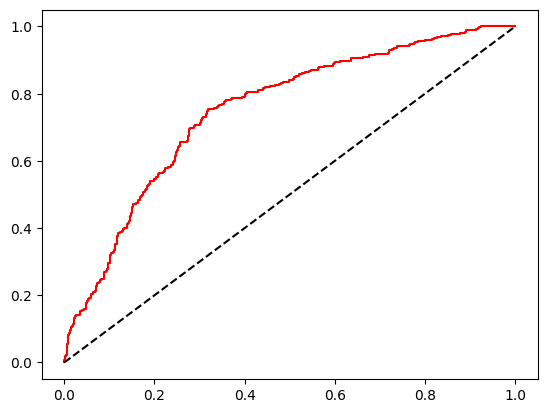

In [50]:
auc=roc_auc_score(y_train,y_pred_train)
print(auc)
plt.plot(fpr,tpr,color='red',data="logistic_model")
plt.plot([0,1],[0,1],'k--')


### 8.1 Test auc curvely

0.7253792641019193


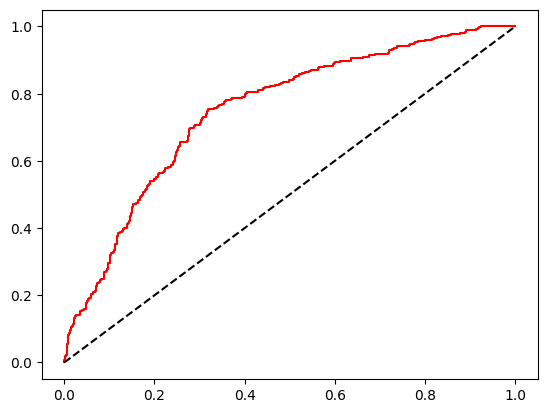

In [51]:
auc=roc_auc_score(y_test,y_pred_test)
print(auc)
plt.plot(fpr,tpr,color='red',data="logistic_model")
plt.plot([0,1],[0,1],'k--')


#  THE END

=================================================================================================================================